# CCO14: Re-process Bulk RNA-seq

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

from sklearn.decomposition import PCA

import gseapy as gp

In [21]:
WORK_DIR = "/home/herbert/work/cocultured_organ/workspace/CCO14"
DATA_DIR = "/home/herbert/work/cocultured_organ/data/220720"

In [22]:
os.system(f"mkdir -p {WORK_DIR}")

0

In [23]:
group_names = ["HOWT_1", "HOWT_2", "HOWT_3", "HOET_1", "HOET_2", "HOET_3", ]

# 0. collect data

In [5]:
os.system(f"mkdir -p {WORK_DIR}/data")

0

In [6]:
df = None

for group_name in group_names:
    df_sub = pd.read_csv(f"{DATA_DIR}/{group_name}-JL-0308.counts.genes", header=None, index_col=0, sep='\t')
    df_sub = df_sub.set_axis([group_name, ], axis=1)

    if df is None:
        df = df_sub.copy()
    else:
        df = pd.merge(df, df_sub, left_index=True, right_index=True, how='outer').fillna(0)

In [7]:
df.to_csv(f"{WORK_DIR}/data/raw.tsv", sep='\t')

# 1.

## 1.0 process

In [8]:
df = pd.read_csv(f"{WORK_DIR}/data/raw.tsv", sep='\t', header=0, index_col=0)
print(df.shape)
df.head()

(26366, 6)


,HOWT_1,HOWT_2,HOWT_3,HOET_1,HOET_2,HOET_3
0,,,,,,
A1BG,50,74,106,94,135,132
A1BG-AS1,128,187,165,119,161,119
A1CF,354,379,336,74,73,121
A2M,1739,2634,2212,8697,7976,8367
A2M-AS1,143,210,204,44,66,53


In [9]:
summary_rows = [
    "no_feature",
    "ambiguous",
    "not_aligned",
    "alignment_not_unique",
    "__no_feature",
    "__ambiguous",
    "__not_aligned",
    "__alignment_not_unique",
]

counts = df.drop(index=summary_rows, errors="ignore").copy()

# Make sure everything is numeric
counts = counts.apply(pd.to_numeric)

# Remove completely unexpressed genes
counts = counts.loc[counts.sum(axis=1) > 0]
counts = counts.loc[counts.sum(axis=1) >= 10]

print(counts.shape)
counts.head()

(16980, 6)


,HOWT_1,HOWT_2,HOWT_3,HOET_1,HOET_2,HOET_3
0,,,,,,
A1BG,50,74,106,94,135,132
A1BG-AS1,128,187,165,119,161,119
A1CF,354,379,336,74,73,121
A2M,1739,2634,2212,8697,7976,8367
A2M-AS1,143,210,204,44,66,53


In [10]:
counts_deseq = counts.T
print(counts_deseq.shape)
counts_deseq.head()

(6, 16980)


0,A1BG,A1BG-AS1,A1CF,A2M,A2M-AS1,A4GALT,AAAS,AACS,AACSP1,AADAC,...,ZWILCH,ZWINT,ZXDA,ZXDB,ZXDC,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3
HOWT_1,50,128,354,1739,143,125,853,447,114,2,...,302,576,63,209,735,3,986,1460,1080,828
HOWT_2,74,187,379,2634,210,238,1279,682,192,2,...,453,1015,78,240,981,5,927,1873,1275,980
HOWT_3,106,165,336,2212,204,281,1357,710,180,8,...,426,859,76,246,1087,3,1242,2163,1553,1172
HOET_1,94,119,74,8697,44,302,779,405,41,0,...,129,41,29,147,1569,1,1492,1886,1409,809
HOET_2,135,161,73,7976,66,421,1179,505,70,0,...,171,59,36,175,1284,3,1145,2490,1246,745


In [11]:
metadata = pd.DataFrame(
    {
        "condition": [
            "WT", "WT", "WT",
            "ET", "ET", "ET"
        ]
    },
    index=counts_deseq.index,
)

In [12]:
dds = DeseqDataSet(
    counts=counts_deseq,
    metadata=metadata,
    design="~condition",
)

dds.deseq2()

Fitting size factors...
... done in 0.05 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.81 seconds.

Fitting dispersion trend curve...
... done in 0.23 seconds.

Fitting MAP dispersions...
... done in 0.47 seconds.

Fitting LFCs...
... done in 0.69 seconds.

Calculating cook's distance...
... done in 0.37 seconds.

Replacing 0 outlier genes.



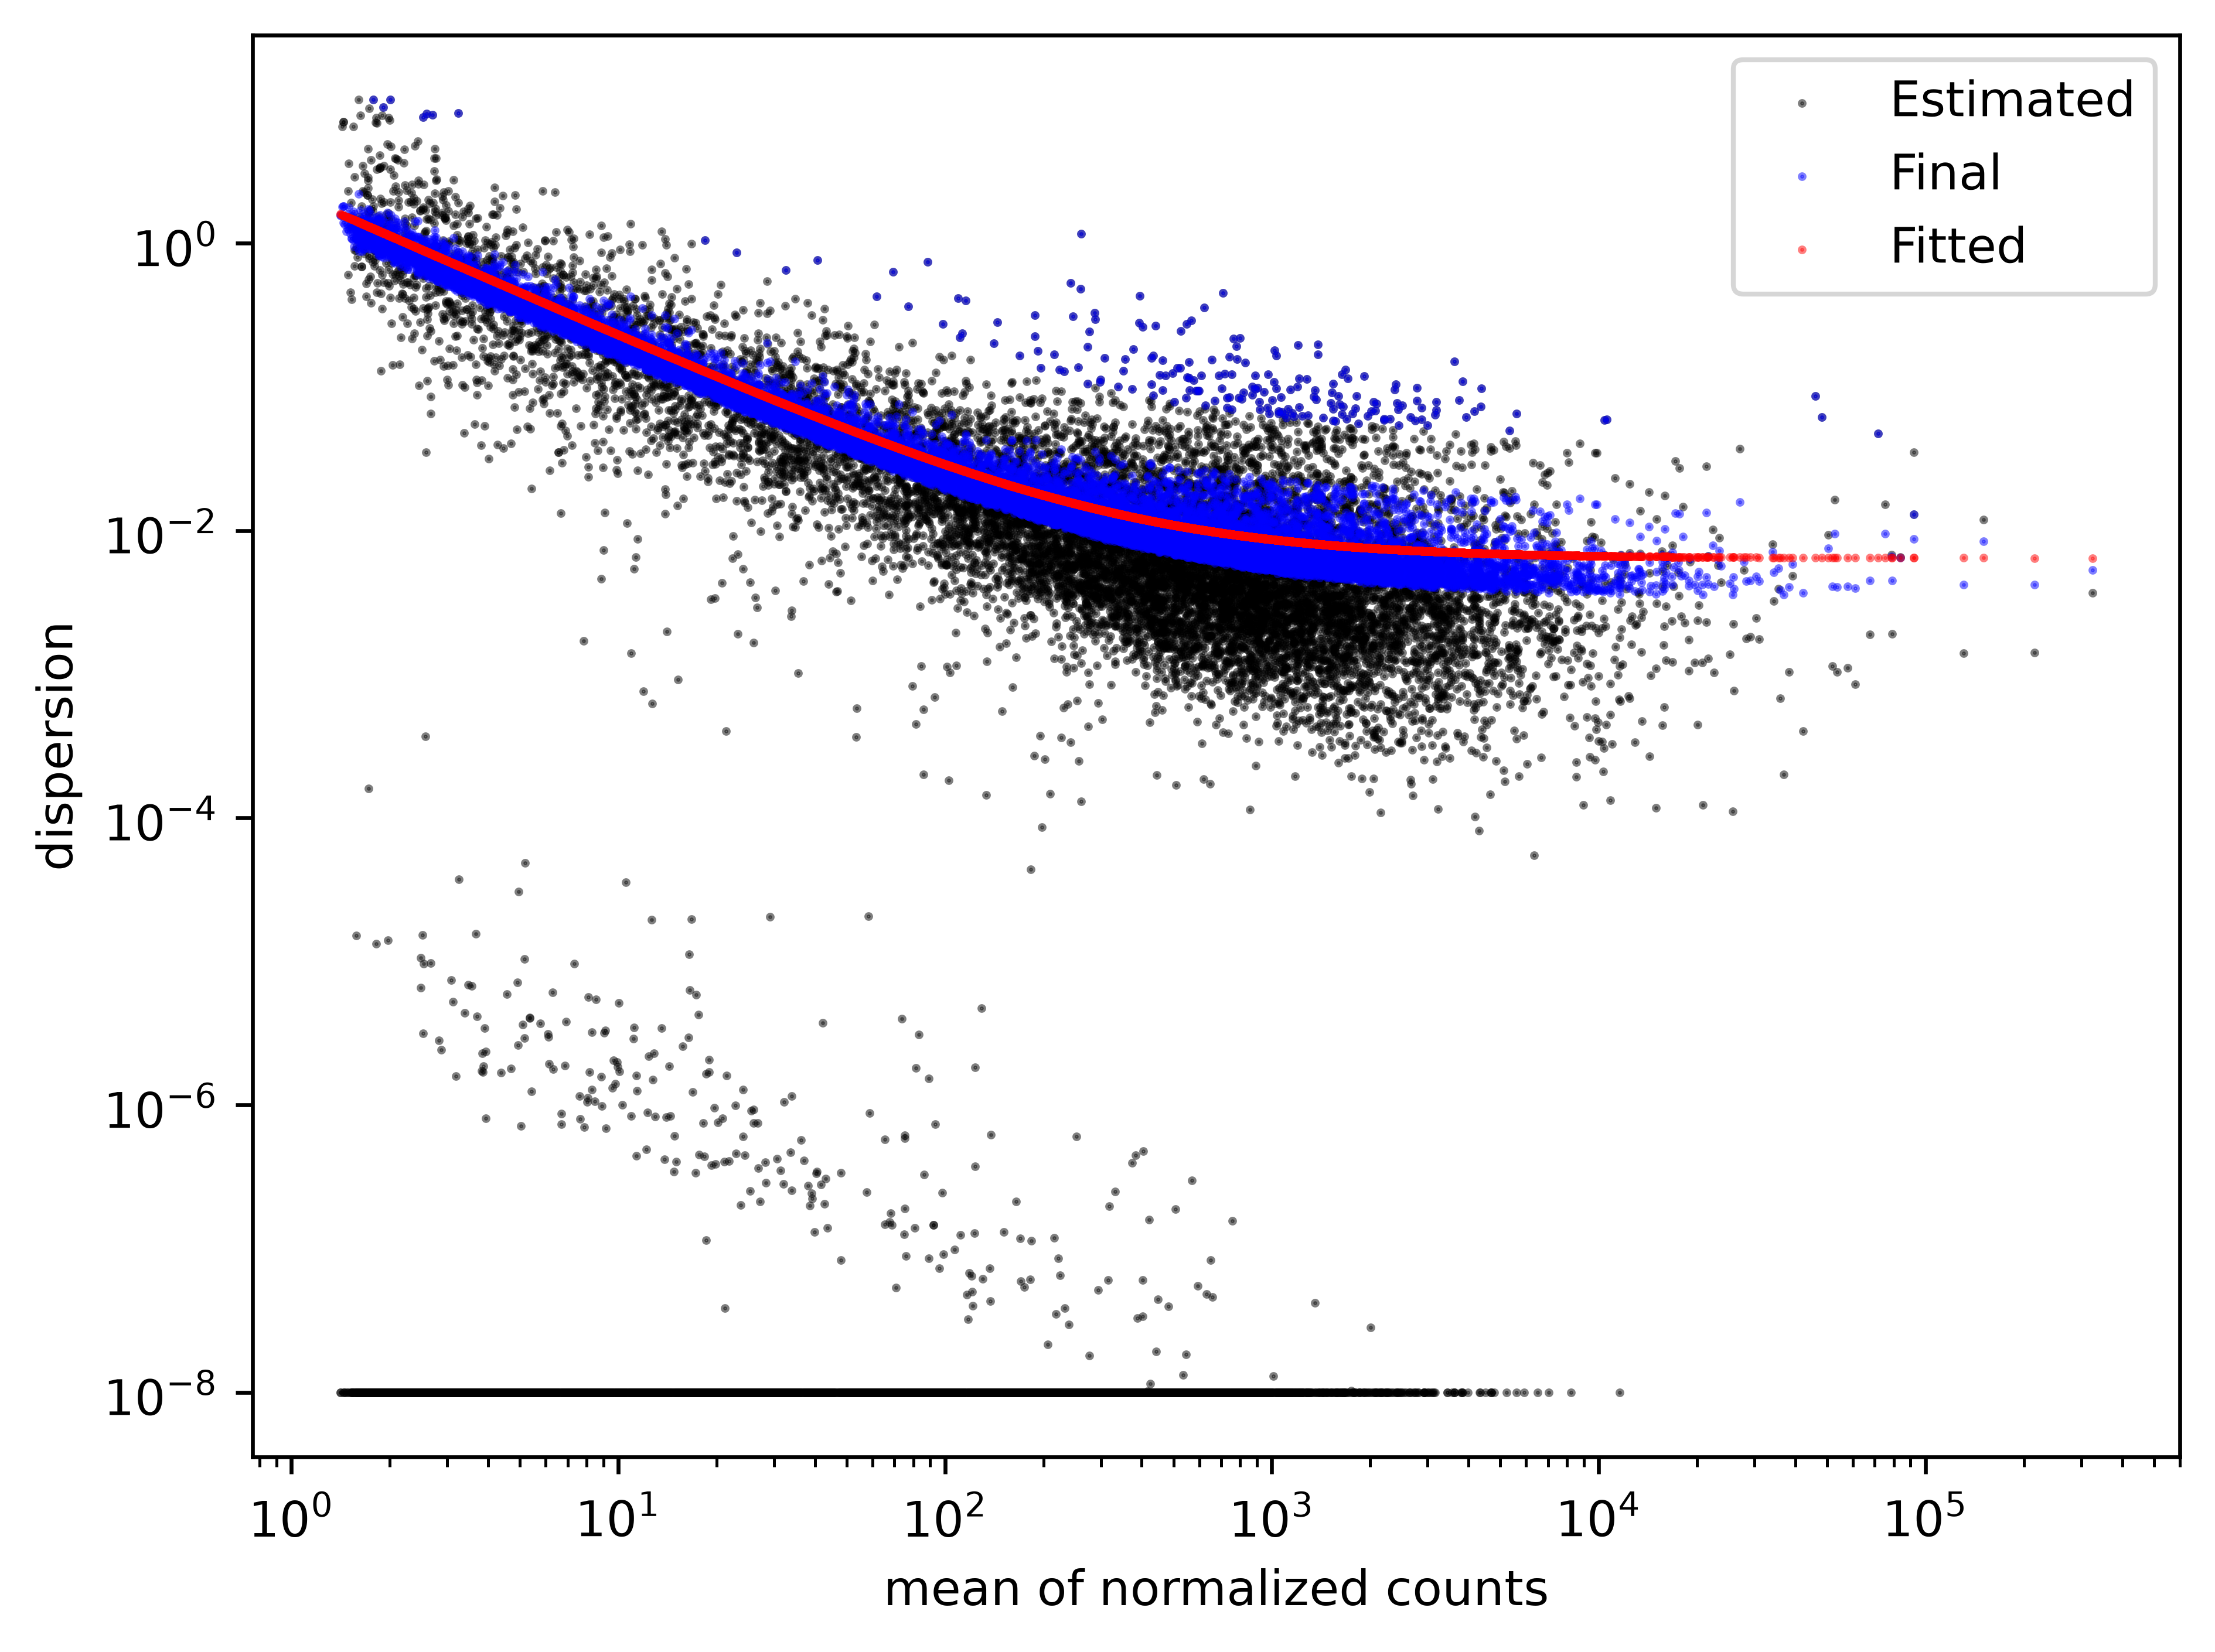

In [13]:
dds.plot_dispersions()

## 1.1 PCA

In [24]:
dds.vst()

vst = pd.DataFrame(
    dds.layers["vst_counts"],
    index=dds.obs_names,
    columns=dds.var_names,
)

Fit type used for VST : parametric
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.27 seconds.

Fitting dispersions...
... done in 2.36 seconds.



In [25]:
pca = PCA(n_components=2)

pcs = pca.fit_transform(vst)

pca_df = pd.DataFrame(
    pcs,
    columns=["PC1", "PC2"],
    index=vst.index,
)

pca_df["condition"] = metadata["condition"]

In [63]:
pca_df["PC1_offset"] = 0
pca_df["PC2_offset"] = 0

pca_df.loc["HOET_1", "PC1_offset"] = -22
pca_df.loc["HOET_1", "PC2_offset"] = -3

pca_df.loc["HOET_2", "PC1_offset"] = -25
pca_df.loc["HOET_2", "PC2_offset"] = -1

pca_df.loc["HOET_3", "PC1_offset"] = -17
pca_df.loc["HOET_3", "PC2_offset"] = 1

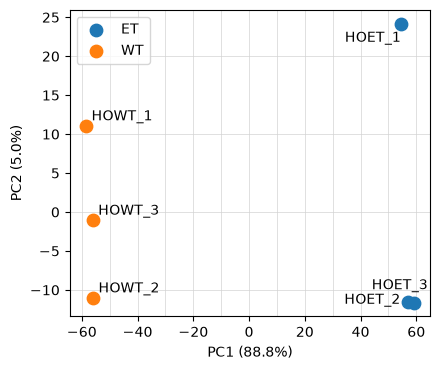

In [65]:
fig, ax = plt.subplots(figsize=(4.5, 3.8))

for condition, group in pca_df.groupby("condition"):
    ax.scatter(
        group["PC1"],
        group["PC2"],
        s=80,
        label=condition
    )

for sample, row in pca_df.iterrows():
    ax.annotate(
        sample,
        (row["PC1"]+row["PC1_offset"], row["PC2"]+row["PC2_offset"]),
        xytext=(4, 4),
        textcoords="offset points"
    )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")

ax.legend(loc='upper left')

for x in np.arange(-60, 61, 10):
    ax.axvline(x, linewidth=0.5, alpha=1, zorder=0, color="lightgrey")
for y in np.arange(-10, 21, 10):
    ax.axhline(y, linewidth=0.5, alpha=1, zorder=0, color="lightgrey")

plt.tight_layout()
plt.savefig(f"{WORK_DIR}/PCA.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/PCA.svg", bbox_inches="tight")
plt.show()

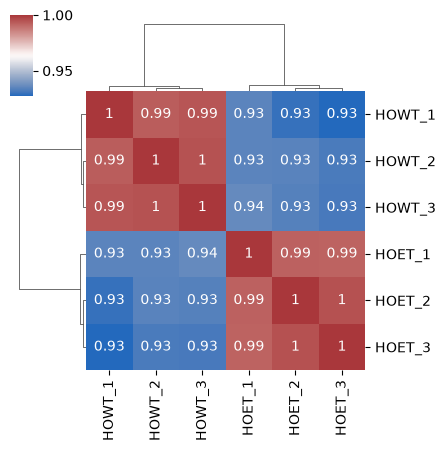

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = vst.T.corr()

sns.clustermap(
    corr,
    cmap="vlag",
    annot=True,
    figsize=(4.5, 4.5)
)

plt.savefig(f"{WORK_DIR}/distance.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/distance.svg", bbox_inches="tight")
plt.show()

## 1.2 DEG

In [80]:
FC = 1
FDR = 0.001

FC_CAP = 8
FDR_CAP = 1e-200

s = 5
alpha = 0.6

In [68]:
stat_res = DeseqStats(
    dds,
    contrast=["condition", "ET", "WT"],
)

stat_res.summary()

Running Wald tests...
... done in 13.09 seconds.



Log2 fold change & Wald test p-value: condition ET vs WT
             baseMean  log2FoldChange     lfcSE       stat        pvalue  \
0                                                                          
A1BG        97.498594        0.839201  0.223564   3.753739  1.742165e-04   
A1BG-AS1   144.241246       -0.098436  0.189191  -0.520301  6.028541e-01   
A1CF       216.544365       -1.855681  0.212490  -8.733014  2.479753e-18   
A2M       5433.288995        2.106533  0.124095  16.975100  1.255408e-64   
A2M-AS1    114.471632       -1.601485  0.209731  -7.635902  2.242442e-14   
...               ...             ...       ...        ...           ...   
ZYG11A       2.412725       -1.312133  1.317001  -0.996304  3.191027e-01   
ZYG11B    1136.338543        0.376749  0.177838   2.118503  3.413248e-02   
ZYX       2033.668832        0.478626  0.089119   5.370673  7.844314e-08   
ZZEF1     1284.898772        0.163618  0.126278   1.295704  1.950774e-01   
ZZZ3       856.147855       -0.

In [69]:
res = stat_res.results_df.copy()
sig = res[
    (res["padj"] < FDR) &
    (res["log2FoldChange"].abs() >= FC)
].copy()

sig = sig.sort_values("padj")
up = sig[sig["log2FoldChange"] >= FC]
down = sig[sig["log2FoldChange"] <= -FC]

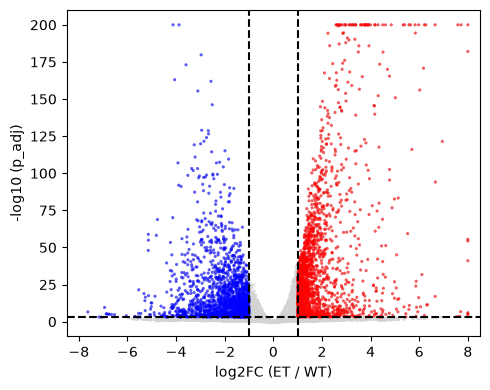

In [81]:
plot_df = res.dropna(subset=["padj"]).copy()

plot_df["minus_log10_padj"] = -np.log10(
    plot_df["padj"].clip(lower=FDR_CAP)
)

plot_df["log2FoldChange"] = plot_df["log2FoldChange"].clip(lower=-FC_CAP, upper=FC_CAP)

plot_df["significant"] = (
    (plot_df["padj"] < FDR) &
    (plot_df["log2FoldChange"].abs() >= FC)
)

fig, ax = plt.subplots(figsize=(5, 4))

ax.scatter(
    plot_df["log2FoldChange"],
    plot_df["minus_log10_padj"],
    label="not signi.",
    s=s,
    color="lightgrey",
    alpha=alpha, 
    edgecolors="none"
)

plot_df_sign = plot_df[plot_df["minus_log10_padj"] > -np.log10(FDR)]

ax.scatter(
    plot_df_sign[plot_df_sign["log2FoldChange"] < -FC]["log2FoldChange"],
    plot_df_sign[plot_df_sign["log2FoldChange"] < -FC]["minus_log10_padj"],
    label="down reg.",
    s=s,
    color="blue",
    alpha=alpha, 
    edgecolors="none"
)

ax.scatter(
    plot_df_sign[plot_df_sign["log2FoldChange"] > FC]["log2FoldChange"],
    plot_df_sign[plot_df_sign["log2FoldChange"] > FC]["minus_log10_padj"],
    label="up reg.",
    s=s,
    color="red",
    alpha=alpha, 
    edgecolors="none"
)

ax.axvline(-FC, linestyle="--", color="black")
ax.axvline(FC, linestyle="--", color="black")
ax.axhline(-np.log10(FDR), linestyle="--", color="black")
ax.set_xlim(-FC_CAP-0.5, FC_CAP+0.5)

ax.set_xlabel("log2FC (ET / WT)")
ax.set_ylabel("-log10 (p_adj)")

plt.tight_layout()
plt.savefig(f"{WORK_DIR}/volcano.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/volcano.svg", bbox_inches="tight")
plt.show()

## 1.3 GOEA

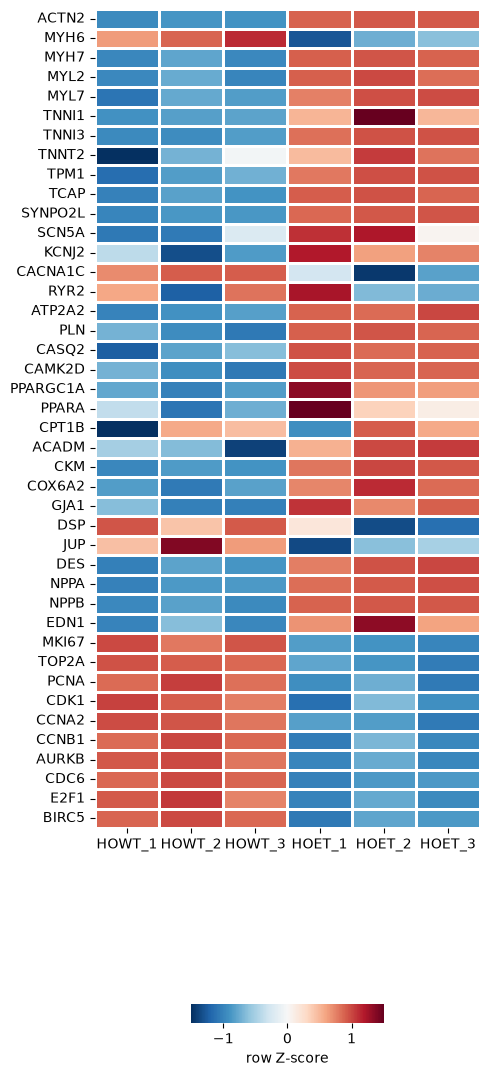

In [98]:
deg_dict = {
    "ACTN2", "MYH6", "MYH7", "MYL2", "MYL7", "TNNI1", "TNNI3", "TNNT2", "TPM1", "TCAP", "SYNPO2L",
    "SCN5A", "KCNJ2", "CACNA1C", "RYR2", "ATP2A2", "PLN", "CASQ2", "CAMK2D", "PPARGC1A", 
    "PPARA", "CPT1B", "ACADM", "CKM", "COX6A2", 
    "GJA1", "DSP", "JUP", "DES",
    "NPPA", "NPPB", "EDN1", 
    "MKI67", "TOP2A", "PCNA", "CDK1", "CCNA2", "CCNB1", "AURKB", "CDC6", "E2F1", "BIRC5",
}

heatmap_data = vst.loc[:, deg].T

heatmap_z = heatmap_data.sub(
    heatmap_data.mean(axis=1), axis=0
).div(
    heatmap_data.std(axis=1), axis=0
)

plt.figure(figsize=(5, 12))

sns.heatmap(
    heatmap_z,
    cmap="RdBu_r",
    center=0,
    cbar_kws={"label": "row Z-score", "orientation": "horizontal", "shrink": 0.5, "aspect": 10},
    vmin=-1.5,
    vmax=1.5,
    linewidths=1, 
    linecolor="white"
)

plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.savefig(f"{WORK_DIR}/heatmap.png", bbox_inches="tight")
plt.savefig(f"{WORK_DIR}/heatmap.svg", bbox_inches="tight")
plt.show()